In [1]:
from fileinput import filename
import xarray as xr
from pathlib import Path
import numpy as np
import os
import matplotlib as mpl


In [20]:
fit_ccic=xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc_new.nc').diurnal_fit_values

In [ ]:
imerg_data = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023.nc').pr
imerg_data_utc = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023_utc.nc').pr
imerg_fit = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc_new.nc").diurnal_fit_values

ccic_data = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023.nc').tiwp
ccic_data_utc = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023.nc').tiwp
fit_ccic=xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc_new.nc').diurnal_fit_values

imerg_phase_utc = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc.nc").diurnal_phase
phase_ccic_utc = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc.nc').diurnal_phase

# change lon to 0-360
imerg_data = imerg_data.assign_coords(lon=(((imerg_data.lon + 360) % 360)))
imerg_data_utc = imerg_data_utc.assign_coords(lon=(((imerg_data_utc.lon + 360) % 360)))
imerg_fit = imerg_fit.assign_coords(lon=(((imerg_fit.lon + 360) % 360)))
ccic_data = ccic_data.assign_coords(lon=(((ccic_data.lon + 360) % 360)))
ccic_data_utc = ccic_data_utc.assign_coords(lon=(((ccic_data_utc.lon + 360) % 360)))
fit_ccic = fit_ccic.assign_coords(lon=(((fit_ccic.lon + 360) % 360)))
phase_ccic_utc = phase_ccic_utc.assign_coords(lon=(((phase_ccic_utc.lon + 360) % 360)))
imerg_phase_utc = imerg_phase_utc.assign_coords(lon=(((imerg_phase_utc.lon + 360) % 360)))

def shift_phase_to_lst(phase_da, lon_da):
    """Shift phase from UTC to local solar time using longitude array.
    Args:
        phase_da (xr.DataArray): phase in UTC, dims (..., lat, lon)
        lon_da (xr.DataArray): longitude array, dims (lon,) or (..., lon)
    Returns:
        xr.DataArray: phase in local solar time (LST)
    """
    # Broadcast lon to match phase_da dimensions
    lon2d = xr.broadcast(phase_da, lon_da)[1]
    phase_lst = phase_da + (lon2d / 360.0) * 24
    phase_lst = xr.where(phase_lst <= 24, phase_lst, phase_lst - 24)
    return phase_lst

imerg_phase_lst = shift_phase_to_lst(imerg_phase_utc, imerg_phase_utc.lon)
phase_ccic_lst = shift_phase_to_lst(phase_ccic_utc, phase_ccic_utc.lon)


seasons_months = [
    [12, 1, 2],  # DJF
    [3, 4, 5],   # MAM
    [6, 7, 8],   # JJA
    [9, 10, 11]  # SON']
]
imerg_sin_cos = xr.Dataset(
    {
        "phase_cos": np.cos(2 * np.pi * imerg_phase_lst / 24),
        "phase_sin": np.sin(2 * np.pi * imerg_phase_lst / 24),
    }
)
ccic_sin_cos = xr.Dataset(
    {
        "phase_cos": np.cos(2 * np.pi * phase_ccic_lst / 24),
        "phase_sin": np.sin(2 * np.pi * phase_ccic_lst / 24),
    }
)

In [10]:
seasons_imerg_data=[]
seasons_imerg_data_utc=[]
seasons_imerg_fit=[]
seasons_imerg_phase=[]
seasons_ccic_data=[]
seasons_ccic_data_utc=[]
seasons_fit_ccic=[]
seasons_phase_ccic=[]
for months in seasons_months:
    seasons_imerg_data.append(imerg_data.sel(month=months).mean(dim='month'))
    seasons_imerg_data_utc.append(imerg_data_utc.sel(month=months).mean(dim='month'))
    seasons_imerg_fit.append(imerg_fit.sel(month=months).mean(dim='month'))
    seasons_ccic_data.append(ccic_data.sel(month=months).mean(dim='month'))
    seasons_ccic_data_utc.append(ccic_data_utc.sel(month=months).mean(dim='month'))
    seasons_fit_ccic.append(fit_ccic.sel(month=months).mean(dim='month'))
    seasons_phase_ccic.append(ccic_sin_cos.sel(month=months).mean(dim='month'))  
    seasons_imerg_phase.append(imerg_sin_cos.sel(month=months).mean(dim='month'))
seasons_imerg_data_avg = xr.concat(seasons_imerg_data, dim='season')
seasons_imerg_data_utc_avg = xr.concat(seasons_imerg_data_utc, dim='season')
seasons_imerg_fit_avg = xr.concat(seasons_imerg_fit, dim='season')
seasons_ccic_data_avg = xr.concat(seasons_ccic_data, dim='season')
seasons_ccic_data_utc_avg = xr.concat(seasons_ccic_data_utc, dim='season')
seasons_fit_ccic_avg = xr.concat(seasons_fit_ccic, dim='season')
seasons_phase_ccic_avg = xr.concat(seasons_phase_ccic, dim='season')
seasons_imerg_phase_avg = xr.concat(seasons_imerg_phase, dim='season')

In [11]:
seasons_imerg_data_sa = seasons_imerg_data_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_imerg_data_utc_sa = seasons_imerg_data_utc_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_imerg_fit_sa = seasons_imerg_fit_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_ccic_data_sa = seasons_ccic_data_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_ccic_data_utc_sa = seasons_ccic_data_utc_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_fit_ccic_sa = seasons_fit_ccic_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_phase_ccic_sa = seasons_phase_ccic_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_imerg_phase_sa = seasons_imerg_phase_avg.sel(lat=slice(-15,0), lon=slice(285, 320))

In [12]:
def weighted_average(da):
    weights = np.cos(np.deg2rad(da['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    avg = da.weighted(weights).mean(dim=["lat", "lon"])
    return avg

In [13]:
seasons_imerg_data_sa_avg = weighted_average(seasons_imerg_data_sa)
seasons_imerg_data_utc_sa_avg = weighted_average(seasons_imerg_data_utc_sa)
seasons_imerg_fit_sa_avg = weighted_average(seasons_imerg_fit_sa)
seasons_ccic_data_sa_avg = weighted_average(seasons_ccic_data_sa)
seasons_ccic_data_utc_sa_avg = weighted_average(seasons_ccic_data_utc_sa)
seasons_fit_ccic_sa_avg = weighted_average(seasons_fit_ccic_sa)
seasons_phase_ccic_sa_avg = weighted_average(seasons_phase_ccic_sa)
seasons_imerg_phase_sa_avg = weighted_average(seasons_imerg_phase_sa)

In [14]:
sin_mean_ccic = seasons_phase_ccic_sa_avg.phase_sin
cos_mean_ccic = seasons_phase_ccic_sa_avg.phase_cos
theta_mean_ccic = np.arctan2(sin_mean_ccic, cos_mean_ccic)
theta_mean_ccic = theta_mean_ccic % (2 * np.pi)

seasons_phase_ccic_sa_avg = 24 * theta_mean_ccic / (2 * np.pi)

sin_mean_imerg = seasons_imerg_phase_sa_avg.phase_sin
cos_mean_imerg = seasons_imerg_phase_sa_avg.phase_cos
theta_mean_imerg = np.arctan2(sin_mean_imerg, cos_mean_imerg)
theta_mean_imerg = theta_mean_imerg % (2 * np.pi)
seasons_phase_imerg_sa_avg = 24 * theta_mean_imerg / (2 * np.pi)

Text(0.5, 1.0, 'Diurnal Cycle of Precipitation - DJF')

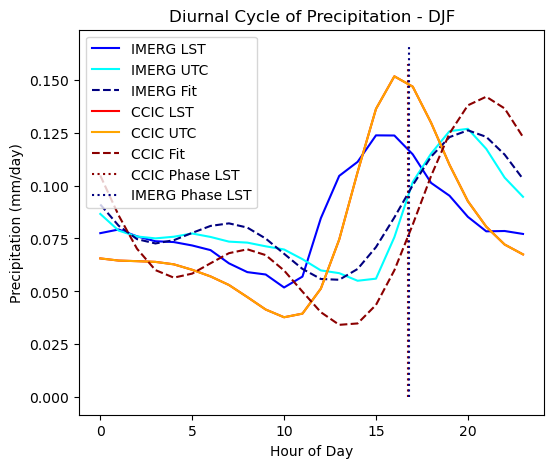

In [15]:
# Winter, plot everything
season_idx = 2  # DJF
import matplotlib.pyplot as plt
seasons_imerg_data_sa_avg.sel(season=season_idx)
seasons_imerg_data_utc_sa_avg.sel(season=season_idx)
seasons_imerg_fit_sa_avg.sel(season=season_idx)
seasons_phase_imerg_sa_avg.sel(season=season_idx)
seasons_ccic_data_sa_avg.sel(season=season_idx)
seasons_ccic_data_utc_sa_avg.sel(season=season_idx)
seasons_fit_ccic_sa_avg.sel(season=season_idx)
seasons_phase_ccic_sa_avg.sel(season=season_idx)
fig, axs = plt.subplots(1, 1, figsize=(6,5))
axs.plot(seasons_imerg_data_sa_avg.sel(season=season_idx).hour_of_day, seasons_imerg_data_sa_avg.sel(season=season_idx), label='IMERG LST', color='blue')
axs.plot(seasons_imerg_data_utc_sa_avg.sel(season=season_idx).hour_of_day, seasons_imerg_data_utc_sa_avg.sel(season=season_idx), label='IMERG UTC', color='cyan')
axs.plot(seasons_imerg_fit_sa_avg.sel(season=season_idx).hour_of_day, seasons_imerg_fit_sa_avg.sel(season=season_idx), label='IMERG Fit', color='navy', linestyle='--')
axs.plot(seasons_ccic_data_sa_avg.sel(season=season_idx).hour_of_day, seasons_ccic_data_sa_avg.sel(season=season_idx), label='CCIC LST', color='red')
axs.plot(seasons_ccic_data_utc_sa_avg.sel(season=season_idx).hour_of_day, seasons_ccic_data_utc_sa_avg.sel(season=season_idx), label='CCIC UTC', color='orange')
axs.plot(seasons_fit_ccic_sa_avg.sel(season=season_idx).hour_of_day, seasons_fit_ccic_sa_avg.sel(season=season_idx), label='CCIC Fit', color='darkred', linestyle='--')
axs.vlines(seasons_phase_ccic_sa_avg.sel(season=season_idx), ymin=0, ymax=axs.get_ylim()[1], colors='darkred', linestyles='dotted', label='CCIC Phase LST')
axs.vlines(seasons_phase_imerg_sa_avg.sel(season=season_idx), ymin=0, ymax=axs.get_ylim()[1], colors='navy', linestyles='dotted', label='IMERG Phase LST')
axs.legend()
axs.set_xlabel('Hour of Day')
axs.set_ylabel('Precipitation (mm/day)')
axs.set_title('Diurnal Cycle of Precipitation - DJF')

In [3]:
seasons_months = [
    [12, 1, 2],  # DJF
    [3, 4, 5],   # MAM
    [6, 7, 8],   # JJA
    [9, 10, 11]  # SON']
]

regions_plot = {
    "Africa": {"color": "#c2896c", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#8fa9b5", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#bd5172", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#797bd0", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#77587e", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#c86c62", "lon": [285, 320], "lat": [-15, 0]},
}

In [4]:
def seasonal_diurnal(ds, region, months):
    ds = ds.assign_coords(lon=(((ds.lon + 360) % 360)))

    seasons_ds = ds.sel(month=months).mean(dim='month')

    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))

    # Conversion to LST
    utc_hour = ds['hour_of_day']
    lst = (utc_hour + ds['lon'] / 360 * 24) % 24
    seasons_ds_region_lst = seasons_ds_region.assign_coords(LST=lst)

    seasons_ds_region_lst_stack = (
        seasons_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1))
        .mean('points')
    )
    
    # Weighted average
    weights = np.cos(np.deg2rad(seasons_ds_region_lst['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    seasons_ds_region_lst_avg = seasons_ds_region_lst_stack.weighted(weights).mean(dim=["lat"])

    return seasons_ds_region_lst_avg

In [5]:
def seasonal_diurnal_utc(ds, region, months):
    ds = ds.assign_coords(lon=(((ds.lon + 360) % 360)))

    seasons_ds = ds.sel(month=months).mean(dim='month')

    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))

    
    # Weighted average
    weights = np.cos(np.deg2rad(seasons_ds_region['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    seasons_ds_region_lst_avg = seasons_ds_region.weighted(weights).mean(dim=["lat", "lon"])

    return seasons_ds_region_lst_avg

In [6]:
def shift_phase_to_lst(phase_da, lon_da):
    """Shift phase from UTC to local solar time using longitude array.
    Args:
        phase_da (xr.DataArray): phase in UTC, dims (..., lat, lon)
        lon_da (xr.DataArray): longitude array, dims (lon,) or (..., lon)
    Returns:
        xr.DataArray: phase in local solar time (LST)
    """
    # Broadcast lon to match phase_da dimensions
    lon2d = xr.broadcast(phase_da, lon_da)[1]
    phase_lst = phase_da + (lon2d / 360.0) * 24
    phase_lst = xr.where(phase_lst <= 24, phase_lst, phase_lst - 24)
    return phase_lst

imerg_phase_lst = shift_phase_to_lst(imerg_phase_utc, imerg_phase_utc.lon)
phase_ccic_lst = shift_phase_to_lst(phase_ccic_utc, phase_ccic_utc.lon)


In [12]:
def seasonal_diurnal_phase(phase_da, region, months):
    phase_da = phase_da.assign_coords(lon=(((phase_da.lon + 360) % 360)))

    phase_da = shift_phase_to_lst(phase_da, phase_da.lon)

    sin_cos = xr.Dataset(
    {
        "phase_cos": np.cos(2 * np.pi * phase_da / 24),
        "phase_sin": np.sin(2 * np.pi * phase_da / 24),
    })

    seasons_sin_cos = sin_cos.sel(month=months).mean(dim='month')
    seasons_sin_cos_region = seasons_sin_cos.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))
    
    # Weighted average
    weights = np.cos(np.deg2rad(seasons_sin_cos_region['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    seasons_sin_cos_region_avg = seasons_sin_cos_region.weighted(weights).mean(dim=["lat", "lon"])
    sin_mean = seasons_sin_cos_region_avg.phase_sin
    cos_mean = seasons_sin_cos_region_avg.phase_cos
    theta_mean = np.arctan2(sin_mean, cos_mean)
    theta_mean = theta_mean % (2 * np.pi)
    seasons_phase_region_avg = 24 * theta_mean / (2 * np.pi)
    return seasons_phase_region_avg

In [22]:
imerg_data_utc = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023_utc.nc').pr
imerg_fit = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc_new.nc").diurnal_fit_values

ccic_data_utc = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023_utc.nc').tiwp
fit_ccic=xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc_new.nc').diurnal_fit_values

imerg_phase_utc = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc.nc").diurnal_phase
phase_ccic_utc = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc.nc').diurnal_phase


In [18]:
seasons_imerg_data_sa_avg = seasonal_diurnal(imerg_data_utc, regions_plot['South America'], [12, 1, 2])
seasons_imerg_data_utc_sa_avg = seasonal_diurnal_utc(imerg_data_utc, regions_plot['South America'], [12, 1, 2])
seasons_imerg_fit_sa_avg = seasonal_diurnal(imerg_fit, regions_plot['South America'], [12, 1, 2])
seasons_ccic_data_sa_avg = seasonal_diurnal(ccic_data_utc, regions_plot['South America'], [12, 1, 2])
seasons_ccic_data_utc_sa_avg = seasonal_diurnal_utc(ccic_data_utc, regions_plot['South America'], [12, 1, 2])
seasons_fit_ccic_sa_avg = seasonal_diurnal(fit_ccic, regions_plot['South America'], [12, 1, 2])
seasons_phase_ccic_sa_avg = seasonal_diurnal_phase(phase_ccic_utc, regions_plot['South America'], [12, 1, 2])
seasons_phase_imerg_sa_avg = seasonal_diurnal_phase(imerg_phase_utc, regions_plot['South America'], [12, 1, 2])

Text(0.5, 1.0, 'Diurnal Cycle of Precipitation - DJF')

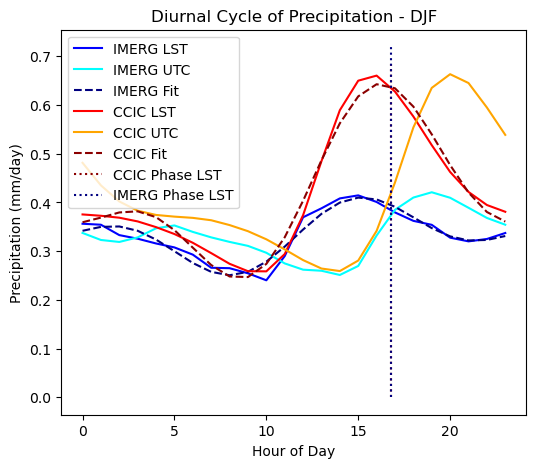

In [19]:
# Winter, plot everything
from matplotlib import pyplot as plt
fig, axs = plt.subplots(1, 1, figsize=(6,5))
axs.plot(range(0,24), seasons_imerg_data_sa_avg, label='IMERG LST', color='blue')
axs.plot(range(0,24), seasons_imerg_data_utc_sa_avg, label='IMERG UTC', color='cyan')
axs.plot(range(0,24), seasons_imerg_fit_sa_avg, label='IMERG Fit', color='navy', linestyle='--')
axs.plot(range(0,24), seasons_ccic_data_sa_avg, label='CCIC LST', color='red')
axs.plot(range(0,24), seasons_ccic_data_utc_sa_avg, label='CCIC UTC', color='orange')
axs.plot(range(0,24), seasons_fit_ccic_sa_avg, label='CCIC Fit', color='darkred', linestyle='--')
axs.vlines(seasons_phase_ccic_sa_avg, ymin=0, ymax=axs.get_ylim()[1], colors='darkred', linestyles='dotted', label='CCIC Phase LST')
axs.vlines(seasons_phase_imerg_sa_avg, ymin=0, ymax=axs.get_ylim()[1], colors='navy', linestyles='dotted', label='IMERG Phase LST')
axs.legend()
axs.set_xlabel('Hour of Day')
axs.set_ylabel('Precipitation (mm/day)')
axs.set_title('Diurnal Cycle of Precipitation - DJF')

In [45]:
ds = imerg_data_utc.assign_coords(lon=(((imerg_data_utc.lon + 360) % 360)))
seasons_ds = ds.sel(month=[12,1,2]).mean(dim='month')
utc_hour = ds['hour_of_day']
lst = (utc_hour + ds['lon'] / 360 * 24) % 24
seasons_ds_region_lst = seasons_ds.assign_coords(LST=lst)


In [51]:
seasons_ds_region_lst_map = []
for lon in seasons_ds_region_lst.lon:
    seasons_ds_region_lst_stack = (
        seasons_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1))
        .mean('points')
    )
    seasons_ds_region_lst_map.append(seasons_ds_region_lst_stack)

seasons_ds_region_lst_map = xr.concat(seasons_ds_region_lst_map, dim='lon')
    


In [53]:
seasons_ds_region_lst_map = seasons_ds_region_lst_map.transpose('LST_bins', 'lat', 'lon')

In [55]:
peak_times = seasons_ds_region_lst_map.argmax(dim='LST_bins')

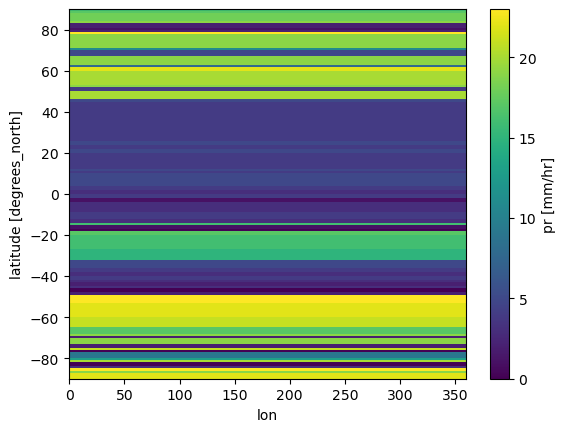

In [56]:
peak_times.plot()

In [ ]:
ds = ds.assign_coords(lon=(((ds.lon + 360) % 360)))

    seasons_ds = ds.sel(month=months).mean(dim='month')

    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))

    # Conversion to LST
    utc_hour = ds['hour_of_day']
    lst = (utc_hour + ds['lon'] / 360 * 24) % 24
    seasons_ds_region_lst = seasons_ds_region.assign_coords(LST=lst)

    seasons_ds_region_lst_stack = (
        seasons_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1))
        .mean('points')
    )